In [1]:
import os
import joblib
import numpy as np
import pandas as pd
from datetime import datetime

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
try:
    from xgboost import XGBRegressor
    xgboost_available = True
except Exception:
    xgboost_available = False

# Explainability
try:
    import shap
    shap_available = True
except Exception:
    shap_available = False


In [4]:
import matplotlib.pyplot as plt

In [5]:
#1. Loading dataset
DATA_PATH = "Desktop/dataset.csv"
df = pd.read_csv(DATA_PATH)

In [6]:
#2. Basic cleaning:

#Dropping rows where target is missing
df = df.dropna(subset=["price"]).reset_index(drop=True)


In [7]:
#Basic feature engineering:

current_year = datetime.now().year
df["age"] = current_year - df["year"]

In [8]:
#Mileage: some entries may be zero or extreme; create log_mileage
#adding small constant to avoid log(0)
df["mileage"] = df["mileage"].fillna(df["mileage"].median())
df["log_mileage"] = np.log1p(df["mileage"])

In [9]:
#Filling numeric missing values with median
for col in ["cylinders", "doors"]:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with 'Unknown'
categorical_cols = [
    "make", "model", "fuel", "transmission", "trim", "body",
    "exterior_color", "interior_color", "drivetrain"
]
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown").astype(str)


In [10]:
# Description and engine: fill unknown
for col in ["description", "engine", "name"]:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown").astype(str)

In [11]:
# 3. Feature selection

#Using a mixed set: numeric, categorical, and TF-IDF on description
features_numeric = ["age", "log_mileage", "cylinders", "doors"]
#keeping only those that exist
features_numeric = [c for c in features_numeric if c in df.columns]

#Chooseing categorical features; limit high-cardinality handling to top-K
categorical_features_all = [c for c in categorical_cols if c in df.columns]

#For high-cardinality columns like model, make: keep top K and mark others as 'Other'
TOP_K = 30  # tune if desired

def top_k_categoricals(X, top_k=TOP_K, cols=None):
    """Transformer to map categorical columns to top_k categories, others -> 'Other'."""
    X = X.copy()
    for col in cols:
        top = X[col].value_counts().nlargest(top_k).index
        X[col] = X[col].where(X[col].isin(top), other="Other")
    return X

#Using TF-IDF on 'description' (limit features)
TEXT_COLUMN = "description"

In [12]:
# 4. Train/test split

TARGET = "price"
X = df.copy()
y = X[TARGET].values
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

#Applying top-K mapping on training and test sets (to avoid unseen heavy cardinality)
X_train_full = top_k_categoricals(X_train_full, cols=categorical_features_all)
X_test_full = top_k_categoricals(X_test_full, cols=categorical_features_all)


In [13]:
# 5. Build preprocessing pipelines
#Numeric pipeline
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

#Categorical pipeline: OneHotEncode (after limiting categories)
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Text pipeline: TF-IDF
tfidf = TfidfVectorizer(max_features=500, stop_words="english")

#ColumnTransformer: combine numeric, categorical, text
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, features_numeric),
    ("cat", categorical_transformer, categorical_features_all),
    ("text", Pipeline([("tfidf", FunctionTransformer(
        lambda df: tfidf.fit_transform(df[TEXT_COLUMN]).toarray() if isinstance(df, pd.DataFrame) else tfidf.transform(df)
    ))]), [TEXT_COLUMN])  # apply custom transformer that expects a DataFrame slice
], remainder="drop", sparse_threshold=0)


In [14]:
# 6. Models to compare

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
}
if xgboost_available:
    models["XGBoost"] = XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42, n_jobs=-1)

In [15]:
# 7. Helper to build final pipeline (fit TF-IDF separately)

def build_pipeline(model, tfidf_vectorizer=None):
    """
    Returns a sklearn Pipeline which:
     - applies numeric + categorical preprocessing
     - appends TF-IDF features (we'll fit tfidf_vectorizer outside and pass it in)
     - trains model
    """
    #Creating a column transformer that handles numeric and categorical only.
    col_transform = ColumnTransformer(transformers=[
        ("num", numeric_transformer, features_numeric),
        ("cat", categorical_transformer, categorical_features_all)
    ], remainder="drop", sparse_threshold=0)

    #Pipeline: preprocess numeric+cat -> combine with TF-IDF externally
    pipe = Pipeline(steps=[
        ("preproc_nc", col_transform),
        ("model", model)
    ])
    return pipe

In [16]:
# 8. Prepare TF-IDF on training descriptions

tfidf = TfidfVectorizer(max_features=500, stop_words="english")
tfidf_train = tfidf.fit_transform(X_train_full[TEXT_COLUMN].fillna(""))

#Precompute transformed numeric+cat matrices for training and test to concatenate with tfidf output
def transform_nc(col_transformer, df_input):
    """Helper to transform numeric+cat using a fitted ColumnTransformer (we'll fit using training df)."""
    return col_transformer.transform(df_input)

#fitting ColumnTransformer on training for numeric+cat
col_transform = ColumnTransformer(transformers=[
    ("num", numeric_transformer, features_numeric),
    ("cat", categorical_transformer, categorical_features_all)
], remainder="drop", sparse_threshold=0)

col_transform.fit(X_train_full)

#Transform training and test numeric+cat
X_train_nc = col_transform.transform(X_train_full)
X_test_nc = col_transform.transform(X_test_full)

#transform TF-IDF
X_train_tfidf = tfidf.transform(X_train_full[TEXT_COLUMN].fillna(""))
X_test_tfidf = tfidf.transform(X_test_full[TEXT_COLUMN].fillna(""))

#Concatenating numeric+cat arrays with tfidf arrays
from scipy import sparse

X_train_final = sparse.hstack([sparse.csr_matrix(X_train_nc), X_train_tfidf]).tocsr()
X_test_final = sparse.hstack([sparse.csr_matrix(X_test_nc), X_test_tfidf]).tocsr()

In [17]:
# 9. Finally Training & Evaluating our models
results = {}
fitted_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    # fit model to X_train_final
    model.fit(X_train_final, y_train)
    # predict
    preds = model.predict(X_test_final)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}
    fitted_models[name] = model
    print(f"  RMSE: ${rmse:,.2f}  MAE: ${mae:,.2f}  R2: {r2:.4f}")

print("\nModel comparison:")
for name, metrics in results.items():
    print(f" - {name}: RMSE=${metrics['RMSE']:,.2f}, MAE=${metrics['MAE']:,.2f}, R2={metrics['R2']:.4f}")


Training LinearRegression...
  RMSE: $33,008.88  MAE: $19,144.99  R2: -2.5678

Training RandomForest...
  RMSE: $8,547.62  MAE: $5,661.73  R2: 0.7608

Training XGBoost...
  RMSE: $7,679.48  MAE: $5,003.19  R2: 0.8069

Model comparison:
 - LinearRegression: RMSE=$33,008.88, MAE=$19,144.99, R2=-2.5678
 - RandomForest: RMSE=$8,547.62, MAE=$5,661.73, R2=0.7608
 - XGBoost: RMSE=$7,679.48, MAE=$5,003.19, R2=0.8069



Best model based on RMSE: XGBoost


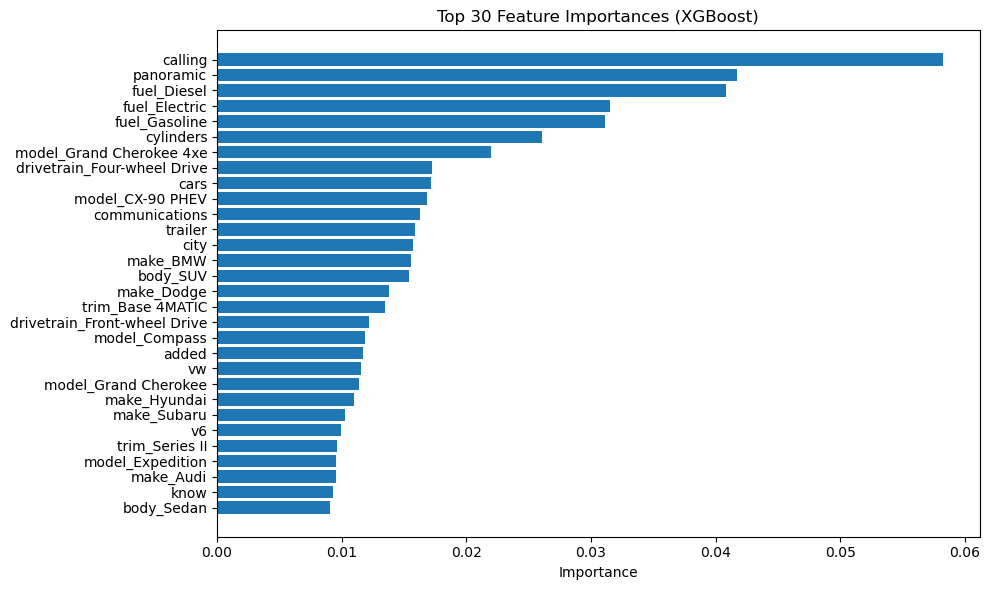

In [18]:
# 10. Feature importance (for tree models)

best_model_name = min(results.items(), key=lambda kv: kv[1]["RMSE"])[0]
best_model = fitted_models[best_model_name]
print(f"\nBest model based on RMSE: {best_model_name}")

# Numeric features
numeric_names = features_numeric

# Categorical one-hot names:
ohe = col_transform.named_transformers_["cat"].named_steps["onehot"]
# get feature names for categorical
try:
    cat_feature_names = ohe.get_feature_names_out(categorical_features_all).tolist()
except Exception:
    # fallback: create generic names
    cat_feature_names = []
    for c in categorical_features_all:
        vals = col_transform.transformers_[1][1].named_steps["onehot"].categories_
        # not guaranteed—this block is a fallback and may not be used in many sklearn versions
        cat_feature_names.append(c)

#TF-IDF feature names
tfidf_feature_names = tfidf.get_feature_names_out().tolist()

feature_names = numeric_names + cat_feature_names + tfidf_feature_names

# If tree-based model, plot feature importances (only first N)
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    # Some models may expect dense arrays; ensure importances length matches
    n_show = 30
    idx = np.argsort(importances)[-n_show:][::-1]
    top_feats = [(feature_names[i] if i < len(feature_names) else f"f{i}", importances[i]) for i in idx]
    # Plot
    names = [t[0] for t in top_feats]
    vals = [t[1] for t in top_feats]
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(vals))[::-1], vals)
    plt.yticks(range(len(vals)), names[::-1])
    plt.title(f"Top {n_show} Feature Importances ({best_model_name})")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print("Best model does not provide feature_importances_ attribute.")


Computing SHAP values (sampled) ...


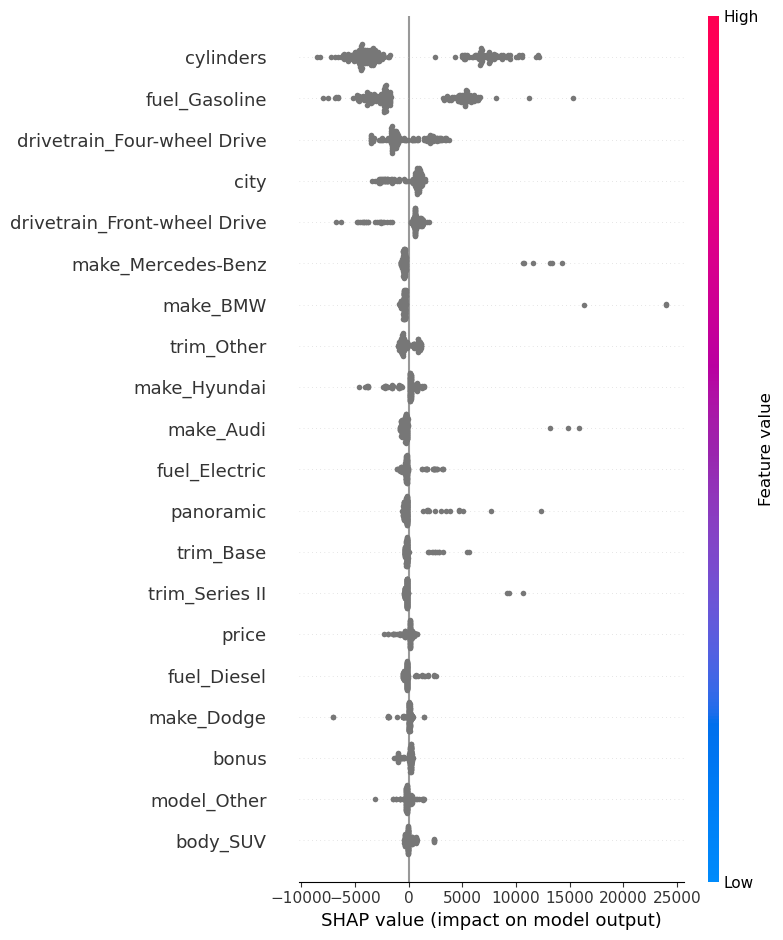

In [19]:
# 11. SHAP explanations
if shap_available and hasattr(best_model, "predict"):
    print("\nComputing SHAP values (sampled) ...")
    try:
        # Use TreeExplainer for tree models, KernelExplainer for others
        if best_model_name in ("RandomForest", "XGBoost"):
            explainer = shap.TreeExplainer(best_model)
            # sample subset (to keep SHAP fast)
            sample_idx = np.random.choice(X_test_final.shape[0], size=min(200, X_test_final.shape[0]), replace=False)
            shap_values = explainer.shap_values(X_test_final[sample_idx])
            # summary plot (requires shap package display support)
            shap.summary_plot(shap_values, features=X_test_final[sample_idx], feature_names=feature_names)
        else:
            print("SHAP KernelExplainer could be used, but is slower. Skipping for linear model.")
    except Exception as e:
        print("Error computing SHAP:", e)
else:
    print("\nSHAP not available or not installed. To enable SHAP, pip install shap.")

In [20]:
# 12. Save the best model and preprocessing artifacts
OUTPUT_DIR = "model_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save tfidf and col_transform (numeric+cat)
joblib.dump(tfidf, os.path.join(OUTPUT_DIR, "tfidf_vectorizer.joblib"))
joblib.dump(col_transform, os.path.join(OUTPUT_DIR, "col_transformer.joblib"))
# Save best model
joblib.dump(best_model, os.path.join(OUTPUT_DIR, f"{best_model_name}_model.joblib"))

print(f"\nSaved TF-IDF, ColumnTransformer and best model to '{OUTPUT_DIR}/'")


Saved TF-IDF, ColumnTransformer and best model to 'model_output/'


In [21]:
# 13. Utility: Predict function for new rows
def predict_single(sample_dict):
    """
    sample_dict example:
    {
      "year": 2018, "mileage": 35000, "cylinders": 4, "doors": 4,
      "make": "Toyota", "model": "Camry", "fuel": "Gasoline",
      "transmission": "Automatic", "trim": "LE", "body": "Sedan",
      "exterior_color": "White", "interior_color": "Black",
      "drivetrain": "Front-wheel Drive", "description": "Well maintained..."
    }
    """
    #building a DataFrame row
    row = pd.DataFrame([sample_dict])
    # Ensure required fields exist
    if "year" in row.columns:
        row["age"] = current_year - row["year"]
    if "mileage" in row.columns:
        row["log_mileage"] = np.log1p(row["mileage"].fillna(0))
    
    
    
    # Filling missing required cols
    for col in categorical_features_all + features_numeric + [TEXT_COLUMN]:
        if col not in row.columns:
            if col in categorical_features_all:
                row[col] = "Unknown"
            elif col in features_numeric:
                row[col] = 0
            elif col == TEXT_COLUMN:
                row[col] = "Unknown"

    # Apply top-k mapping to categorical columns (use same top-K mapping seen during train)
    row = top_k_categoricals(row, cols=categorical_features_all)

    # Transform numeric+cat
    nc = col_transform.transform(row)
    # Transform text
    tf = tfidf.transform(row[TEXT_COLUMN].fillna(""))
    X_row = sparse.hstack([sparse.csr_matrix(nc), tf]).tocsr()
    pred = best_model.predict(X_row)
    return pred[0]

In [22]:
#Thankyou very much!